In [1]:
import itertools

import jax
import jax.numpy as jnp
import jax.random as jr
import matplotlib.pyplot as plt
import matplotlib_inline
import optax
import seaborn as sns
from IPython.display import Markdown

%matplotlib inline
matplotlib_inline.backend_inline.set_matplotlib_formats("svg", "pdf")
jax.config.update("jax_enable_x64", True)

key = jr.PRNGKey(0)
colors = sns.color_palette()

In [2]:
# BOOK_FIGURE_STYLE_CELL
from pathlib import Path

import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np

try:
    import seaborn as sns
except ImportError:
    sns = None

try:
    import matplotlib_inline

    matplotlib_inline.backend_inline.set_matplotlib_formats("svg", "pdf")
except Exception:
    matplotlib_inline = None

FIGURE_SIZES = {
    "full_landscape": (4.50, 2.20),
    "full_standard": (4.50, 3.55),
    "full_tall": (4.50, 4.30),
    "half_standard": (3.20, 2.35),
    "half_tall": (3.20, 2.85),
    "inset": (2.30, 1.75),
}

BOOK_COLORS = {
    "blue": "#4C78A8",
    "orange": "#F58518",
    "green": "#54A24B",
    "red": "#E45756",
    "gray": "#7F7F7F",
}

BOOK_TARGET = "web"


def setup_book_style(target="web"):
    global BOOK_TARGET
    BOOK_TARGET = target
    mpl.rcParams.update(
        {
            "figure.figsize": FIGURE_SIZES["half_standard"],
            "figure.dpi": 120,
            "savefig.dpi": 300,
            "savefig.bbox": "tight",
            "savefig.pad_inches": 0.02,
            "font.family": "sans-serif",
            "font.sans-serif": ["DejaVu Sans", "Arial", "Liberation Sans"],
            "axes.labelsize": 9,
            "axes.titlesize": 9,
            "axes.linewidth": 0.8,
            "axes.grid": False,
            "axes.spines.top": False,
            "axes.spines.right": False,
            "xtick.labelsize": 8,
            "ytick.labelsize": 8,
            "xtick.major.width": 0.8,
            "ytick.major.width": 0.8,
            "legend.fontsize": 8,
            "legend.frameon": False,
            "lines.linewidth": 1.5,
            "lines.markersize": 4,
            "patch.linewidth": 0.8,
            "image.cmap": "viridis",
        }
    )
    if target == "latex":
        try:
            mpl.rcParams["text.usetex"] = False
        except Exception:
            mpl.rcParams["text.usetex"] = False


def new_figure(
    size="half_standard",
    nrows=1,
    ncols=1,
    sharex=False,
    sharey=False,
    constrained=True,
    squeeze=True,
    **kwargs,
):
    fig, ax = plt.subplots(
        nrows=nrows,
        ncols=ncols,
        sharex=sharex,
        sharey=sharey,
        constrained_layout=constrained,
        figsize=FIGURE_SIZES[size],
        squeeze=squeeze,
        **kwargs,
    )
    return fig, ax


def label_panels(axes=None, labels=None, x=0.02, y=0.98, **kwargs):
    if axes is None:
        axes = plt.gcf().axes
    axes = np.atleast_1d(axes).ravel()
    if labels is None:
        labels = [f"({chr(97 + i)})" for i in range(len(axes))]
    default = dict(
        fontsize=9,
        fontweight="semibold",
        va="top",
        ha="left",
        transform=None,
    )
    default.update(kwargs)
    for ax, label in zip(axes, labels):
        call_kwargs = dict(default)
        if call_kwargs["transform"] is None:
            call_kwargs["transform"] = ax.transAxes
        ax.text(x, y, label, **call_kwargs)


def finalize_axes(axes=None, keep_box=False, grid=False):
    if axes is None:
        axes = plt.gcf().axes
    axes = np.atleast_1d(axes).ravel()
    for ax in axes:
        if grid:
            ax.grid(axis="y", color="0.88", linewidth=0.6)
        else:
            ax.grid(False)
        for spine in ax.spines.values():
            spine.set_linewidth(0.8)
        if keep_box:
            ax.spines["top"].set_visible(True)
            ax.spines["right"].set_visible(True)
        else:
            ax.spines["top"].set_visible(False)
            ax.spines["right"].set_visible(False)
    return axes


def save_book_figure(fig, basename, target="web", pdf=True, png=False):
    base = Path(basename)
    base.parent.mkdir(parents=True, exist_ok=True)
    if pdf:
        fig.savefig(base.with_suffix(".pdf"), bbox_inches="tight", pad_inches=0.02)
    if png:
        fig.savefig(base.with_suffix(".png"), bbox_inches="tight", pad_inches=0.02)


setup_book_style(target="web")


# Example: 3D Particle Position Reconstruction from Images

This example implements a small synthetic version of the stochastic volumetric reconstruction method of {cite:t}`hans2023stochastic`.

The paper proposes a Bayesian reconstruction method for 3D particle locations from synchronized multi-camera images. Its predicted intensity on camera $m$ is

$$
f_m(z) = I_0 \sum_{n=1}^N \exp\left(-\frac{\|z - h_m(x_n)\|^2}{2\sigma_{\mathrm{img}}^2}\right),
$$

where:

- $x_n \in \mathbb{R}^3$ are candidate particle positions,
- $h_m$ is the calibration map for camera $m$,
- $z \in \mathbb{R}^2$ is a location on the image plane of camera $m$, $I_0$ is the peak particle intensity, and $\sigma_{\mathrm{img}}$ is the image-plane blob width.

As in the paper, we deliberately use **more candidate particles than the true number of particles**. Variational inference then tries to explain the images while an additional quadratic term encourages unnecessary particles to drift away from the imaging region.

## Simplifications in this teaching example

We keep the main structure of the method, but simplify several parts:

- We use three synthetic cameras with linear projection maps instead of a full laboratory calibration model.
- We use a diagonal Gaussian guide for the candidate particle locations.
- We optimize a Monte Carlo estimate of the ELBO with Adam.
- After optimization, we cluster nearby candidates to remove duplicates and identify the reconstructed particles.

These simplifications retain the variational reconstruction of a sparse 3D particle field directly from image data.


## Synthetic multi-camera dataset

We place three particles in a cubic domain and render them onto three cameras. Each particle contributes a Gaussian blob on every image plane. We then add independent, zero-mean Gaussian pixel noise and treat the resulting images as observations. We retain negative noisy intensities in the likelihood and use a zero lower intensity limit only for display. The resulting observations are shown in {numref}`fig-particle-camera-observations`.


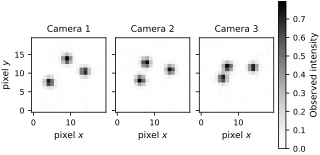

In [3]:
height = 20
width = 20
num_true_particles = 3
num_candidate_particles = 5

peak_intensity = 0.8
particle_spread = 0.9
noise_std = 0.01

prior_scale = 2.0
penalty_strength = 0.5
repulsion_strength = 0.05
repulsion_length = 0.06

learning_rate = 3e-3
num_steps = 2500
num_mc_samples = 32

camera_matrices = jnp.array(
    [
        [[1.00, 0.00, 0.00], [0.00, 1.00, 0.00]],
        [[0.85, 0.10, 0.55], [0.02, 0.95, 0.22]],
        [[0.93, -0.18, 0.34], [0.06, 0.90, 0.48]],
    ],
    dtype=jnp.float64,
)

true_positions = jnp.array(
    [
        [-0.55, -0.20, 0.25],
        [-0.05, 0.45, -0.35],
        [0.45, 0.10, 0.20],
    ],
    dtype=jnp.float64,
)

row_coords, col_coords = jnp.meshgrid(
    jnp.arange(height), jnp.arange(width), indexing="ij"
)
pixel_grid = jnp.stack([col_coords, row_coords], axis=-1)


def project_points(points, camera_matrix):
    projected = points @ camera_matrix.T
    scale = jnp.array([width - 1, height - 1], dtype=jnp.float64)
    return 0.5 * (projected + 1.0) * scale


def render_camera(points, camera_matrix):
    uv = project_points(points, camera_matrix)
    displacement = pixel_grid[None, :, :, :] - uv[:, None, None, :]
    sqdist = jnp.sum(displacement**2, axis=-1)
    blobs = jnp.exp(-0.5 * sqdist / particle_spread**2)
    return peak_intensity * jnp.sum(blobs, axis=0)


def render_all_cameras(points):
    return jax.vmap(lambda camera_matrix: render_camera(points, camera_matrix))(
        camera_matrices
    )


clean_images = render_all_cameras(true_positions)
observed_images = clean_images + noise_std * jr.normal(jr.PRNGKey(1), clean_images.shape)
# Keep Gaussian observations unbounded for inference.
# The imshow limits below affect the display only.


fig, axes = plt.subplots(
    1,
    3,
    figsize=FIGURE_SIZES["full_landscape"],
    sharex=True,
    sharey=True,
    constrained_layout=True,
)
intensity_limit = float(jnp.max(observed_images))
for idx, ax in enumerate(axes):
    image = ax.imshow(
        observed_images[idx],
        origin="lower",
        cmap="Greys",
        vmin=0.0,
        vmax=intensity_limit,
        interpolation="nearest",
    )
    ax.set_title(f"Camera {idx + 1}")
    ax.set_xlabel("pixel $x$")
axes[0].set_ylabel("pixel $y$")
colorbar = fig.colorbar(image, ax=axes, fraction=0.035, pad=0.02)
colorbar.set_label("Observed intensity")
finalize_axes(axes, keep_box=True)
plt.show()

During inference we treat the particle coordinates used to generate the synthetic data as unknown and instead optimize an approximate posterior over an **overcomplete** set of five candidate particles.

## Variational formulation

Let $X = (x_1, \dots, x_N)$ denote the candidate particle locations and let $M$ be the number of cameras. We use the generative model

$$
p(Y \mid X) = \prod_{m=1}^M \prod_{r,c}
\mathcal{N}\left(
    Y_{mrc} \mid f_m(X)_{rc}, \sigma_\text{noise}^2
\right),
$$

together with a weak Gaussian prior on each coordinate. The guide is a diagonal Gaussian

$$
q_\phi(X) = \prod_{n=1}^N \prod_{\ell=1}^3
\mathcal{N}(x_{n\ell} \mid \mu_{n\ell}, s_{n\ell}^2).
$$

Following the spirit of the paper, we add a positive quadratic term to the ELBO so that candidate particles that are not needed are encouraged to move away from the domain:

$$
\mathcal{L}_{\text{aug}}(\phi)
=
\mathbb{E}_{q_\phi}[\log p(Y, X) - \log q_\phi(X)]
+
\varepsilon
\mathbb{E}_{q_\phi}\left[
    \frac{1}{3N}
    \sum_{n=1}^N \|x_n\|_2^2
\right].
$$

In this synthetic example we also include a very small repulsion term between candidates so that duplicate particles are less attractive numerically.


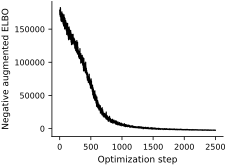

Array([[-0.55077836, -0.20136227,  0.25287222],
       [-1.74078498, -0.08135893, -1.05533435],
       [ 0.4491913 ,  0.0991566 ,  0.20150746],
       [-0.04902262,  0.44876755, -0.34782105],
       [-1.58487621, -1.2124272 , -1.08453771]], dtype=float64)

In [4]:
def unpack_variational_params(phi):
    num_coordinates = num_candidate_particles * 3
    mu = phi[:num_coordinates].reshape(num_candidate_particles, 3)
    log_std = phi[num_coordinates:].reshape(num_candidate_particles, 3)
    return mu, log_std


def pairwise_repulsion(points):
    differences = points[:, None, :] - points[None, :, :]
    sqdist = jnp.sum(differences**2, axis=-1)
    mask = 1.0 - jnp.eye(points.shape[0])
    return jnp.sum(jnp.exp(-sqdist / repulsion_length) * mask) / (
        points.shape[0] * (points.shape[0] - 1)
    )


def augmented_elbo(phi, key):
    mu, log_std = unpack_variational_params(phi)
    std = jnp.exp(log_std)

    epsilon = jr.normal(
        key, (num_mc_samples, num_candidate_particles, 3), dtype=jnp.float64
    )
    samples = mu[None, :, :] + std[None, :, :] * epsilon

    rendered_images = jax.vmap(render_all_cameras)(samples)
    residual = observed_images - rendered_images
    log_likelihood = -0.5 * jnp.sum(
        (residual / noise_std) ** 2, axis=(1, 2, 3)
    )
    log_likelihood -= observed_images.size * jnp.log(
        jnp.sqrt(2.0 * jnp.pi) * noise_std
    )

    log_prior = -0.5 * jnp.sum((samples / prior_scale) ** 2, axis=(1, 2))
    log_prior -= samples.shape[1] * samples.shape[2] * jnp.log(
        jnp.sqrt(2.0 * jnp.pi) * prior_scale
    )

    log_guide = -0.5 * jnp.sum(
        ((samples - mu) / std) ** 2 + 2.0 * log_std + jnp.log(2.0 * jnp.pi),
        axis=(1, 2),
    )

    outward_penalty = penalty_strength * jnp.mean(
        jnp.sum(samples**2, axis=(1, 2))
    ) / (3.0 * num_candidate_particles)

    repulsion = repulsion_strength * jnp.mean(
        jax.vmap(pairwise_repulsion)(samples)
    )

    return jnp.mean(log_likelihood + log_prior - log_guide) + outward_penalty - repulsion


objective_and_grad = jax.jit(
    jax.value_and_grad(lambda phi, key: -augmented_elbo(phi, key))
)


initial_phi = jnp.concatenate(
    [
        0.2 * jr.normal(jr.PRNGKey(2), (num_candidate_particles, 3)).reshape(-1),
        jnp.full((num_candidate_particles * 3,), -1.2, dtype=jnp.float64),
    ]
)

optimizer = optax.adam(learning_rate)
opt_state = optimizer.init(initial_phi)

phi = initial_phi
losses = []
for step in range(num_steps):
    step_key = jr.fold_in(jr.PRNGKey(3), step)
    loss, grad = objective_and_grad(phi, step_key)
    updates, opt_state = optimizer.update(grad, opt_state, phi)
    phi = optax.apply_updates(phi, updates)
    losses.append(loss)

losses = jnp.array(losses)
mu, log_std = unpack_variational_params(phi)
std = jnp.exp(log_std)

fig, ax = plt.subplots(
    figsize=FIGURE_SIZES["half_standard"], constrained_layout=True
)
ax.plot(losses, color="black", linewidth=1.2)
ax.set_xlabel("Optimization step")
ax.set_ylabel("Negative augmented ELBO")
finalize_axes(keep_box=False)
plt.show()

mu

The array above contains the posterior means of the five candidate particles. Some should remain near the three true particles, while the unnecessary ones should move away or become diffuse.


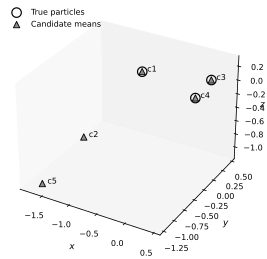

{'candidate_1': {'mean': Array([-0.55077836, -0.20136227,  0.25287222], dtype=float64),
  'std': Array([0.01490007, 0.01105111, 0.01535589], dtype=float64),
  'radius': 0.6386297279072398},
 'candidate_2': {'mean': Array([-1.74078498, -0.08135893, -1.05533435], dtype=float64),
  'std': Array([0.1872365 , 0.22821919, 0.25865313], dtype=float64),
  'radius': 2.037322311779673},
 'candidate_3': {'mean': Array([0.4491913 , 0.0991566 , 0.20150746], dtype=float64),
  'std': Array([0.01360029, 0.01068519, 0.01490371], dtype=float64),
  'radius': 0.5022052450909544},
 'candidate_4': {'mean': Array([-0.04902262,  0.44876755, -0.34782105], dtype=float64),
  'std': Array([0.01215099, 0.01122402, 0.01445432], dtype=float64),
  'radius': 0.5698903525058933},
 'candidate_5': {'mean': Array([-1.58487621, -1.2124272 , -1.08453771], dtype=float64),
  'std': Array([0.1432076 , 0.40274884, 0.24300746], dtype=float64),
  'radius': 2.2711306384619103}}

In [5]:
fig = plt.figure(
    figsize=FIGURE_SIZES["full_standard"], constrained_layout=True
)
ax = fig.add_subplot(111, projection="3d")
ax.scatter(
    true_positions[:, 0],
    true_positions[:, 1],
    true_positions[:, 2],
    marker="o",
    facecolors="none",
    edgecolors="black",
    linewidths=1.2,
    depthshade=False,
    s=90,
    label="True particles",
)
ax.scatter(
    mu[:, 0],
    mu[:, 1],
    mu[:, 2],
    marker="^",
    facecolors="0.55",
    edgecolors="black",
    s=40,
    linewidths=0.9,
    depthshade=False,
    label="Candidate means",
)

for idx in range(num_candidate_particles):
    ax.text(mu[idx, 0], mu[idx, 1], mu[idx, 2], f"  c{idx + 1}", fontsize=8)

ax.set_xlabel("$x$")
ax.set_ylabel("$y$")
ax.set_zlabel("$z$", labelpad=-5)
ax.legend(loc="upper left")
finalize_axes(keep_box=False)
plt.show()

candidate_summary = {
    f"candidate_{idx + 1}": {
        "mean": mu[idx],
        "std": std[idx],
        "radius": float(jnp.linalg.norm(mu[idx])),
    }
    for idx in range(num_candidate_particles)
}
candidate_summary

## Post-processing: identify the reconstructed particles

The variational posterior is defined over an overcomplete set of candidates, so we still need a simple rule for deciding which candidates represent distinct particles. We use two heuristics:

1. Ignore candidates that have drifted too far from the imaging volume.
2. Cluster candidates that are closer than a small distance threshold.

This post-processing turns the overcomplete representation into a sparse reconstructed point cloud. In the stored run, it recovers all three true particles with no extra detected particles; the root mean square coordinate error under the best matching assignment is $0.0015$ in the example's coordinate units.


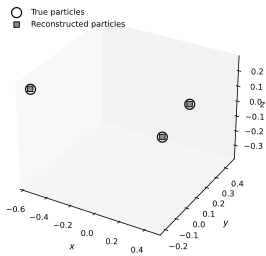


**Reconstruction summary**

- True particles: `3`
- Reconstructed particles after clustering: `3`
- RMS coordinate error against the best matching assignment: `0.0015`
- Ghost fraction after clustering: `0.000`


In [6]:
def cluster_active_particles(candidate_positions, candidate_std, radius_threshold=1.6, merge_threshold=0.18):
    scores = jnp.linalg.norm(candidate_std, axis=1)
    active_particles = []

    for idx in map(int, jnp.argsort(scores)):
        point = candidate_positions[idx]
        if float(jnp.linalg.norm(point)) > radius_threshold:
            continue
        if any(float(jnp.linalg.norm(point - q)) < merge_threshold for q in active_particles):
            continue
        active_particles.append(point)

    if not active_particles:
        return jnp.empty((0, 3), dtype=jnp.float64)
    return jnp.stack(active_particles)


def best_rms_error(reconstructed, reference):
    if reconstructed.shape[0] < reference.shape[0]:
        return jnp.inf, None

    best_error = jnp.inf
    best_subset = None
    reference_indices = tuple(range(reference.shape[0]))
    for subset in itertools.combinations(range(reconstructed.shape[0]), reference.shape[0]):
        subset_points = reconstructed[jnp.array(subset)]
        for perm in itertools.permutations(reference_indices):
            candidate = subset_points[jnp.array(perm)]
            error = jnp.sqrt(jnp.mean((candidate - reference) ** 2))
            if error < best_error:
                best_error = error
                best_subset = candidate
    return best_error, best_subset


reconstructed_particles = cluster_active_particles(mu, std)
rms_error, matched_particles = best_rms_error(reconstructed_particles, true_positions)

fig = plt.figure(
    figsize=FIGURE_SIZES["full_standard"], constrained_layout=True
)
ax = fig.add_subplot(111, projection="3d")
ax.scatter(
    true_positions[:, 0],
    true_positions[:, 1],
    true_positions[:, 2],
    marker="o",
    facecolors="none",
    edgecolors="black",
    linewidths=1.2,
    depthshade=False,
    s=100,
    label="True particles",
)
if reconstructed_particles.shape[0] > 0:
    ax.scatter(
        reconstructed_particles[:, 0],
        reconstructed_particles[:, 1],
        reconstructed_particles[:, 2],
        marker="s",
        facecolors="0.55",
        edgecolors="black",
        linewidths=0.9,
        depthshade=False,
        s=30,
        label="Reconstructed particles",
    )
ax.set_xlabel("$x$")
ax.set_ylabel("$y$")
ax.set_zlabel("$z$", labelpad=-5)
ax.legend(loc="upper left")
finalize_axes(keep_box=False)
plt.show()

num_detected = int(reconstructed_particles.shape[0])
num_true = int(true_positions.shape[0])
num_matches = min(num_detected, num_true)
ghost_fraction = max(num_detected - num_true, 0) / max(num_detected, 1)

Markdown(
    f"""
**Reconstruction summary**

- True particles: `{num_true}`
- Reconstructed particles after clustering: `{num_detected}`
- RMS coordinate error against the best matching assignment: `{float(rms_error):.4f}`
- Ghost fraction after clustering: `{ghost_fraction:.3f}`
"""
)

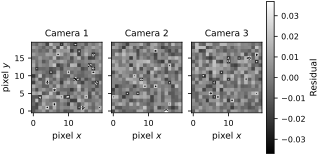

In [7]:
fig, axes = plt.subplots(
    1,
    3,
    figsize=FIGURE_SIZES["full_landscape"],
    sharex=True,
    sharey=True,
    constrained_layout=True,
)
reconstructed_image = render_all_cameras(reconstructed_particles)
residual_images = observed_images - reconstructed_image
residual_limit = float(jnp.max(jnp.abs(residual_images)))
residual_norm = mpl.colors.TwoSlopeNorm(
    vmin=-residual_limit, vcenter=0.0, vmax=residual_limit
)
contour_level = 2.0 * noise_std

for idx, ax in enumerate(axes):
    difference = residual_images[idx]
    image = ax.imshow(
        difference,
        origin="lower",
        cmap="gray",
        norm=residual_norm,
        interpolation="nearest",
    )
    ax.contour(
        difference,
        levels=[-contour_level],
        colors="white",
        linestyles="--",
        linewidths=0.7,
    )
    ax.contour(
        difference,
        levels=[contour_level],
        colors="black",
        linestyles="-",
        linewidths=0.7,
    )
    ax.set_title(f"Camera {idx + 1}")
    ax.set_xlabel("pixel $x$")
axes[0].set_ylabel("pixel $y$")
colorbar = fig.colorbar(image, ax=axes, fraction=0.035, pad=0.02)
colorbar.set_label("Residual")
finalize_axes(axes, keep_box=True)
plt.show()

## Discussion

Stochastic volumetric reconstruction combines a differentiable camera model, a probabilistic model for the unknown particle locations, and a variational approximation of the posterior. The overcomplete candidate set lets optimization suppress unnecessary particles. This small example turns the combinatorial reconstruction problem into continuous optimization over a probabilistic model.
